# Dataset Merger — Combine N Excel Files into One

Merges any number of Excel files that share the same column structure.

**Steps:**
1. Configure source files (explicit list or auto-scan a folder)
2. Validate all files have matching columns
3. Merge and preview
4. Export combined dataset to Excel

In [1]:
!pip install pandas openpyxl matplotlib -q


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

plt.rcParams.update({'figure.dpi': 110})
print('Imports OK')

Imports OK


## ⚙️ Configuration — Edit This Cell

Choose **one** of two modes:

- **`MODE = 'list'`** — provide exact file paths in `FILE_LIST`
- **`MODE = 'folder'`** — auto-scan a folder and pick up all `.xlsx` files

Set `OUTPUT_FILE` to the desired name for the merged output.

In [3]:
# ── MODE ─────────────────────────────────────────────────────────────────────
MODE = 'list'          # 'list'  → use FILE_LIST below
                       # 'folder' → auto-scan FOLDER_PATH for all .xlsx files

# ── Used when MODE = 'list' ──────────────────────────────────────────────────
FILE_LIST = [
    'Complete_Wavelet_Fault_Dataset_AG.xlsx',
    'Complete_Wavelet_Fault_Dataset_nofault.xlsx',
    # Add more files here:
    # 'Complete_Wavelet_Fault_Dataset_BG.xlsx',
    # 'Complete_Wavelet_Fault_Dataset_CG.xlsx',
]

# ── Used when MODE = 'folder' ────────────────────────────────────────────────
FOLDER_PATH   = '.'          # folder to scan (use '.' for current directory)
FILE_PATTERN  = '*.xlsx'     # glob pattern (e.g. 'Complete_*.xlsx')
EXCLUDE_FILES = [            # files to skip (e.g. previous merged outputs)
    'Combined_Dataset.xlsx',
]

# ── Output ───────────────────────────────────────────────────────────────────
OUTPUT_FILE = 'Combined_Dataset.xlsx'

# ── Sheet name inside each Excel file (None = first sheet) ───────────────────
SHEET_NAME = 0

## Step 1 — Discover Files

In [4]:
if MODE == 'folder':
    all_found = glob.glob(os.path.join(FOLDER_PATH, FILE_PATTERN))
    files = [f for f in sorted(all_found)
             if os.path.basename(f) not in EXCLUDE_FILES]
elif MODE == 'list':
    files = FILE_LIST
else:
    raise ValueError(f"MODE must be 'list' or 'folder', got '{MODE}'")

# Verify all files exist
missing = [f for f in files if not os.path.exists(f)]
if missing:
    raise FileNotFoundError(f'These files were not found:\n' + '\n'.join(missing))

print(f'Mode         : {MODE}')
print(f'Files found  : {len(files)}')
print()
for i, f in enumerate(files, 1):
    size_kb = os.path.getsize(f) / 1024
    print(f'  {i:>2}. {os.path.basename(f):<55}  ({size_kb:,.0f} KB)')

Mode         : list
Files found  : 2

   1. Complete_Wavelet_Fault_Dataset_AG.xlsx                   (5,461 KB)
   2. Complete_Wavelet_Fault_Dataset_nofault.xlsx              (5,406 KB)


## Step 2 — Load & Validate Each File

In [5]:
dataframes = []
file_summaries = []
reference_cols = None
issues = []

for i, filepath in enumerate(files):
    fname = os.path.basename(filepath)
    print(f'Loading [{i+1}/{len(files)}]  {fname} ...', end=' ')

    df_i = pd.read_excel(filepath, sheet_name=SHEET_NAME)
    print(f'{df_i.shape[0]:,} rows × {df_i.shape[1]} cols', end='  ')

    # ── Column validation ──────────────────────────────────────────────────
    if reference_cols is None:
        reference_cols = list(df_i.columns)
        col_ok = True
        print('[reference]')
    else:
        if list(df_i.columns) == reference_cols:
            col_ok = True
            print('[✓ columns match]')
        else:
            col_ok = False
            extra   = set(df_i.columns) - set(reference_cols)
            missing = set(reference_cols) - set(df_i.columns)
            issues.append(f'{fname}: extra={extra}, missing={missing}')
            print(f'[✗ COLUMN MISMATCH  extra={extra}  missing={missing}]')

    summary = {
        'File'       : fname,
        'Rows'       : df_i.shape[0],
        'Cols'       : df_i.shape[1],
        'Cols OK'    : col_ok,
        'Missing'    : int(df_i.isna().sum().sum()),
        'Duplicates' : int(df_i.duplicated().sum()),
        'Labels'     : str(sorted(df_i['Fault_Label'].unique().tolist()))
                       if 'Fault_Label' in df_i.columns else 'N/A',
    }
    file_summaries.append(summary)
    dataframes.append((fname, df_i, col_ok))

summary_df = pd.DataFrame(file_summaries)
print()
print(summary_df.to_string(index=False))

if issues:
    print(f'\n⚠️  {len(issues)} file(s) have column mismatches — they will be EXCLUDED from the merge.')
else:
    print('\nAll files passed column validation ✓')

Loading [1/2]  Complete_Wavelet_Fault_Dataset_AG.xlsx ... 10,006 rows × 49 cols  [reference]
Loading [2/2]  Complete_Wavelet_Fault_Dataset_nofault.xlsx ... 10,006 rows × 49 cols  [✓ columns match]

                                       File  Rows  Cols  Cols OK  Missing  Duplicates Labels
     Complete_Wavelet_Fault_Dataset_AG.xlsx 10006    49     True        0           0 [1001]
Complete_Wavelet_Fault_Dataset_nofault.xlsx 10006    49     True        0           0    [0]

All files passed column validation ✓


## Step 3 — Merge

In [6]:
# Only merge files that passed column validation
valid_dfs = [(fname, df_i) for fname, df_i, ok in dataframes if ok]

if len(valid_dfs) == 0:
    raise RuntimeError('No valid files to merge — check column mismatches above.')

# Add a source column so origin is traceable
tagged = []
for fname, df_i in valid_dfs:
    df_copy = df_i.copy()
    df_copy.insert(0, 'Source_File', os.path.splitext(fname)[0])
    tagged.append(df_copy)

combined = pd.concat(tagged, ignore_index=True)

print(f'Files merged  : {len(valid_dfs)}')
print(f'Total rows    : {len(combined):,}')
print(f'Total columns : {combined.shape[1]}  (includes Source_File column)')
print(f'Missing values: {combined.isna().sum().sum()}')
print(f'Duplicates    : {combined.duplicated().sum():,}')
print()
combined.head(10)

Files merged  : 2
Total rows    : 20,012
Total columns : 50  (includes Source_File column)
Missing values: 0
Duplicates    : 0



,Source_File,ia_D1_Energy,ia_D2_Energy,ia_D3_Energy,ia_D4_Energy,ib_D1_Energy,ib_D2_Energy,ib_D3_Energy,ib_D4_Energy,ic_D1_Energy,...,vo_D4_Energy,v1_D1_Energy,v1_D2_Energy,v1_D3_Energy,v1_D4_Energy,v2_D1_Energy,v2_D2_Energy,v2_D3_Energy,v2_D4_Energy,Fault_Label
0,Complete_Wavelet_Fault_Dataset_AG,1.772366e-08,1.864839e-06,2.205896e-05,5.305076e-08,8.337221e-09,9.853265e-07,0.000001,3.979838e-11,1.749066e-09,...,9.533946e-39,9.819305e-08,1.279671e-07,0.000009,1.765879e-07,9.819305e-08,1.326553e-07,0.000008,2.284139e-07,1001
1,Complete_Wavelet_Fault_Dataset_AG,3.947594e-08,1.360242e-05,2.221827e-04,2.389946e-06,2.444879e-08,8.788270e-06,0.000013,1.638780e-09,1.791357e-09,...,3.848153e-37,1.159500e-08,6.448148e-07,0.000056,3.095417e-05,1.159500e-08,5.546592e-07,0.000046,2.106369e-05,1001
2,Complete_Wavelet_Fault_Dataset_AG,3.454916e-08,1.355831e-05,3.570850e-05,1.145754e-04,5.051077e-08,5.263348e-06,0.000002,2.242846e-05,1.511029e-09,...,2.321840e-34,5.644239e-06,1.741960e-04,0.002302,2.567481e-02,5.644239e-06,2.404482e-04,0.006555,8.127308e-03,1001
3,Complete_Wavelet_Fault_Dataset_AG,1.571253e-09,1.794338e-06,5.813193e-08,9.678662e-04,2.005922e-09,2.784765e-06,0.000066,7.424231e-04,2.650686e-11,...,5.870264e-34,1.695684e-04,3.250471e-03,0.056315,3.545374e-01,3.340365e-04,1.037450e-02,0.001329,1.141548e-02,1001
4,Complete_Wavelet_Fault_Dataset_AG,2.402760e-09,8.532159e-07,1.298229e-05,1.113359e-04,6.019620e-10,2.181698e-08,0.000066,6.602119e-04,5.994195e-10,...,1.441853e-33,5.538763e-06,1.698054e-04,0.000004,2.269239e-03,2.630495e-05,1.827818e-02,0.000093,6.783623e-03,1001
5,Complete_Wavelet_Fault_Dataset_AG,1.574016e-09,8.999036e-09,8.702942e-05,1.287196e-03,2.589416e-11,7.732850e-07,0.000006,2.771965e-04,2.003682e-09,...,9.076330e-33,4.604942e-06,1.278336e-06,0.009122,9.332867e-04,2.120939e-04,2.590793e-04,0.002152,1.275052e-03,1001
6,Complete_Wavelet_Fault_Dataset_AG,2.302815e-10,8.891228e-07,1.544644e-04,1.539368e-04,1.073802e-09,4.230397e-07,0.000027,1.266810e-03,2.298622e-09,...,1.377436e-32,2.481430e-07,6.578245e-04,0.000891,5.620312e-05,3.316329e-03,6.543733e-04,0.000009,5.021522e-05,1001
7,Complete_Wavelet_Fault_Dataset_AG,2.286377e-10,2.380474e-07,1.160251e-04,8.088475e-04,2.297556e-09,2.278993e-07,0.000118,2.581132e-05,1.076631e-09,...,7.571867e-33,1.098688e-07,1.349390e-02,0.000022,9.774268e-06,7.452902e-04,1.929714e-02,0.000005,1.372298e-06,1001
8,Complete_Wavelet_Fault_Dataset_AG,1.571578e-09,4.113859e-07,2.500272e-05,8.990501e-04,2.006053e-09,8.938890e-07,0.000154,1.053156e-03,2.647970e-11,...,6.781620e-33,5.504431e-05,2.319895e-03,0.000078,3.554029e-06,4.321620e-07,3.187553e-03,0.000027,2.031158e-06,1001
9,Complete_Wavelet_Fault_Dataset_AG,2.403707e-09,7.819938e-07,7.187135e-06,9.818851e-05,6.021783e-10,1.143544e-08,0.000085,6.318762e-04,5.996763e-10,...,1.594396e-33,2.552297e-05,6.843009e-04,0.000004,3.413313e-06,5.799851e-05,2.392941e-04,0.000003,9.014881e-07,1001


Row contribution per source file:

                                         Rows     %
Source File                                        
Complete_Wavelet_Fault_Dataset_AG       10006  50.0
Complete_Wavelet_Fault_Dataset_nofault  10006  50.0


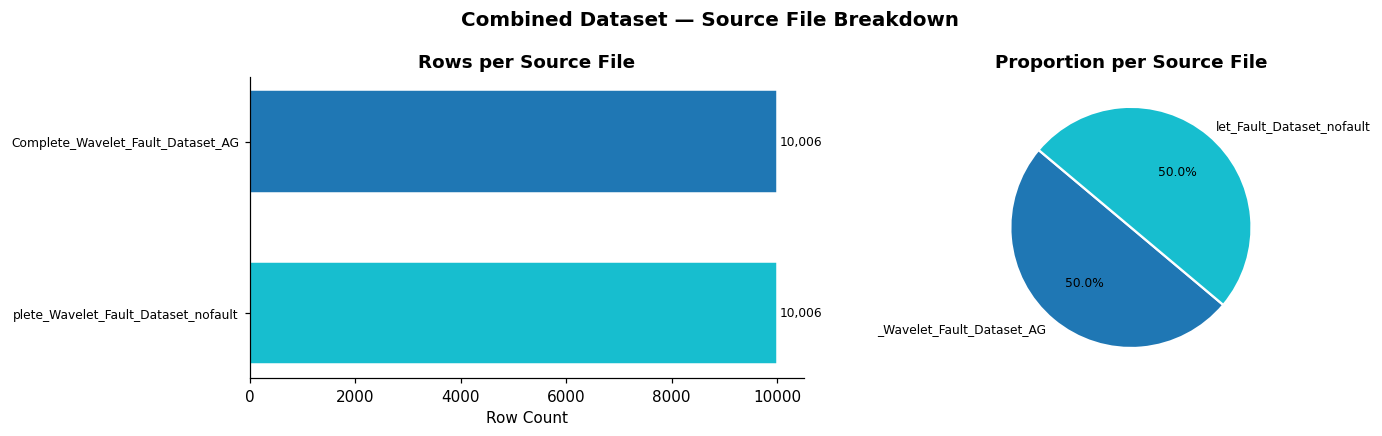

In [7]:
# Row contribution per source file
contrib = combined['Source_File'].value_counts().sort_index()
pct     = (contrib / len(combined) * 100).round(2)

contrib_df = pd.DataFrame({'Rows': contrib, '%': pct})
contrib_df.index.name = 'Source File'
print('Row contribution per source file:\n')
print(contrib_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = plt.cm.tab10(np.linspace(0, 1, len(contrib)))

axes[0].barh(range(len(contrib)), contrib.values, color=colors, edgecolor='white', height=0.6)
axes[0].set_yticks(range(len(contrib)))
axes[0].set_yticklabels([s[-35:] for s in contrib.index], fontsize=8)
for j, v in enumerate(contrib.values):
    axes[0].text(v + len(combined)*0.002, j, f'{v:,}', va='center', fontsize=8)
axes[0].set_xlabel('Row Count'); axes[0].set_title('Rows per Source File', fontweight='bold')
axes[0].spines[['top','right']].set_visible(False); axes[0].invert_yaxis()

axes[1].pie(contrib.values, labels=[s[-25:] for s in contrib.index],
            colors=colors, autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.5),
            textprops=dict(fontsize=8))
axes[1].set_title('Proportion per Source File', fontweight='bold')

plt.suptitle('Combined Dataset — Source File Breakdown', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Fault_Label distribution in combined dataset:

             Count     %
Fault_Label             
0            10006  50.0
1001         10006  50.0


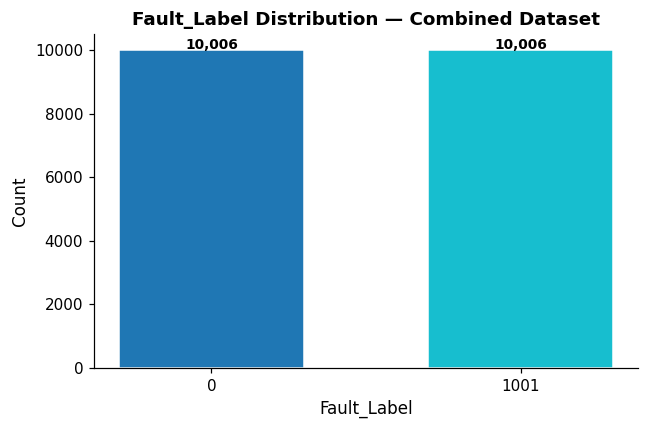

In [8]:
# Label distribution in combined dataset (if Fault_Label exists)
if 'Fault_Label' in combined.columns:
    label_counts = combined['Fault_Label'].value_counts().sort_index()
    label_pct    = (label_counts / len(combined) * 100).round(2)
    label_df     = pd.DataFrame({'Count': label_counts, '%': label_pct})
    label_df.index.name = 'Fault_Label'
    print('Fault_Label distribution in combined dataset:\n')
    print(label_df.to_string())

    fig, ax = plt.subplots(figsize=(max(6, len(label_counts) * 1.2), 4))
    bar_colors = plt.cm.tab10(np.linspace(0, 1, len(label_counts)))
    bars = ax.bar(label_counts.index.astype(str), label_counts.values,
                  color=bar_colors, edgecolor='white', width=0.6)
    for b, v in zip(bars, label_counts.values):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + len(combined)*0.002,
                f'{v:,}', ha='center', fontsize=9, fontweight='bold')
    ax.set_xlabel('Fault_Label', fontsize=11); ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Fault_Label Distribution — Combined Dataset', fontsize=12, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.show()

## Step 4 — Export to Excel

In [9]:
print(f'Writing to {OUTPUT_FILE} ...', end=' ')
combined.to_excel(OUTPUT_FILE, index=False, engine='openpyxl')
size_mb = os.path.getsize(OUTPUT_FILE) / (1024 * 1024)
print(f'Done  ({size_mb:.2f} MB)')
print()
print('=' * 55)
print('EXPORT SUMMARY')
print('=' * 55)
print(f'  Output file   : {OUTPUT_FILE}')
print(f'  File size     : {size_mb:.2f} MB')
print(f'  Total rows    : {len(combined):,}')
print(f'  Total columns : {combined.shape[1]}')
print(f'  Source files  : {len(valid_dfs)}')
for fname, df_i in valid_dfs:
    print(f'    • {fname}  ({len(df_i):,} rows)')
print('=' * 55)

Writing to Combined_Dataset.xlsx ... Done  (10.20 MB)

EXPORT SUMMARY
  Output file   : Combined_Dataset.xlsx
  File size     : 10.20 MB
  Total rows    : 20,012
  Total columns : 50
  Source files  : 2
    • Complete_Wavelet_Fault_Dataset_AG.xlsx  (10,006 rows)
    • Complete_Wavelet_Fault_Dataset_nofault.xlsx  (10,006 rows)


## (Optional) Quick Sanity Check on Output

In [10]:
# Re-read the saved file and verify it matches what we wrote
verify = pd.read_excel(OUTPUT_FILE, engine='openpyxl')

assert verify.shape == combined.shape, 'Shape mismatch!'
assert list(verify.columns) == list(combined.columns), 'Column mismatch!'

print('Sanity check passed ✓')
print(f'  Saved shape   : {verify.shape}')
print(f'  Columns       : {list(verify.columns[:5])} ... {list(verify.columns[-3:])}')
print()
verify.head()

Sanity check passed ✓
  Saved shape   : (20012, 50)
  Columns       : ['Source_File', 'ia_D1_Energy', 'ia_D2_Energy', 'ia_D3_Energy', 'ia_D4_Energy'] ... ['v2_D3_Energy', 'v2_D4_Energy', 'Fault_Label']



,Source_File,ia_D1_Energy,ia_D2_Energy,ia_D3_Energy,ia_D4_Energy,ib_D1_Energy,ib_D2_Energy,ib_D3_Energy,ib_D4_Energy,ic_D1_Energy,...,vo_D4_Energy,v1_D1_Energy,v1_D2_Energy,v1_D3_Energy,v1_D4_Energy,v2_D1_Energy,v2_D2_Energy,v2_D3_Energy,v2_D4_Energy,Fault_Label
0,Complete_Wavelet_Fault_Dataset_AG,1.772366e-08,1.864839e-06,2.205896e-05,5.305076e-08,8.337221e-09,9.853265e-07,0.000001,3.979838e-11,1.749066e-09,...,9.533946e-39,9.819305e-08,1.279671e-07,0.000009,1.765879e-07,9.819305e-08,1.326553e-07,0.000008,2.284139e-07,1001
1,Complete_Wavelet_Fault_Dataset_AG,3.947594e-08,1.360242e-05,2.221827e-04,2.389946e-06,2.444879e-08,8.788270e-06,0.000013,1.638780e-09,1.791357e-09,...,3.848153e-37,1.159500e-08,6.448148e-07,0.000056,3.095417e-05,1.159500e-08,5.546592e-07,0.000046,2.106369e-05,1001
2,Complete_Wavelet_Fault_Dataset_AG,3.454916e-08,1.355831e-05,3.570850e-05,1.145754e-04,5.051077e-08,5.263348e-06,0.000002,2.242846e-05,1.511029e-09,...,2.321840e-34,5.644239e-06,1.741960e-04,0.002302,2.567481e-02,5.644239e-06,2.404482e-04,0.006555,8.127308e-03,1001
3,Complete_Wavelet_Fault_Dataset_AG,1.571253e-09,1.794338e-06,5.813193e-08,9.678662e-04,2.005922e-09,2.784765e-06,0.000066,7.424231e-04,2.650686e-11,...,5.870264e-34,1.695684e-04,3.250471e-03,0.056315,3.545374e-01,3.340365e-04,1.037450e-02,0.001329,1.141548e-02,1001
4,Complete_Wavelet_Fault_Dataset_AG,2.402760e-09,8.532159e-07,1.298229e-05,1.113359e-04,6.019620e-10,2.181698e-08,0.000066,6.602119e-04,5.994195e-10,...,1.441853e-33,5.538763e-06,1.698054e-04,0.000004,2.269239e-03,2.630495e-05,1.827818e-02,0.000093,6.783623e-03,1001
